### 3. პროექტის სათაური: მეორადი ავტომობილების ბაზრის ანალიზი და ფასების დინამიკური რეგრესიული მოდელირება (Predictive Car Pricing)

* **საჭირო მონაცემთა ბაზები:**
  * **მონაცემთა წყარო:** [Kaggle - Vehicle Dataset (From CarDekho)](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho) (რეკომენდებულია ფაილების `car data.csv` ან `Car details v3.csv` გამოყენება).
  * **მონაცემთა მოცულობა და სტრუქტურა:** 1 ფაილი (CSV ფორმატი), $\sim300$-დან $8000$-მდე ჩანაწერი (არჩეული ვერსიის მიხედვით), ტექნიკური და ეკონომიკური მახასიათებლები (გამოშვების წელი, გარბენი, საწვავის ტიპი, ტრანსმისია, საბაზრო ფასი).
* **მინიმალური აკადემიური კრიტერიუმები:**
  * **მონაცემთა მომზადება:** გამოტოვებული მნიშვნელობების მართვა, კატეგორიული ცვლადების ადეკვატური კოდირება და მულტიკოლინეარობის (Multicollinearity) შემოწმება სტატისტიკური ინდიკატორებით (მაგ. VIF).
  * **მახასიათებელთა ინჟინერია:** დროზე დამოკიდებული ახალი პარამეტრების შექმნა (მაგ. აქტივის ასაკი მიმდინარე პერიოდთან მიმართებაში).
  * **მოდელირება:** სხვადასხვა კლასის მათემატიკური მოდელების (ხაზოვანი, ხისებრი ან ანსამბლური არქიტექტურის) შედარება უწყვეტი ცვლადის პროგნოზირებისთვის.
  * **შეცდომების ანალიზი:** მოდელის ხარისხის შეფასება რამდენიმე მეტრიკით, რომლებიც ზომავენ როგორც აბსოლუტურ, ისე ფარდობით ცდომილებას. ნარჩენების გრაფიკული ანალიზი (Residual Analysis) მოდელის სისტემური მიკერძოებების გამოსავლენად.
* **ბონუს დავალებები:**
  * მოდელების გაერთიანების მოწინავე სტრატეგიების (მაგ. `Stacking` ან `Voting`) რეალიზება პროგნოზის მაქსიმალური მდგრადობის მისაღწევად.
  * მონაცემთა დამუშავებისა და მოდელირების სრული ციკლის შეკვრა ერთიან ავტომატიზებულ სტრუქტურად (`Pipeline`), რაც უზრუნველყოფს კოდის მზადყოფნას ახალ, რეალურ მონაცემთა ნაკადებზე სამუშაოდ.
* **შეფასების კომპონენტები:**
  * მონაცემთა მათემატიკური მომზადება და მულტიკოლინეარობის კონტროლი — 30%
  * შერჩეული ალგორითმების მრავალფეროვნება, ვალიდაციის სქემა (Cross-Validation) და მათი ვალიდურობა — 40%
  * ნარჩენების (Residuals) სიღრმისეული ანალიზი და მოდელის შეცდომების ინტერპრეტაცია — 30%

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor

from statsmodels.api import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [5]:
df = pd.read_csv('C:/Users/user/Desktop/car data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


გვაქვს 4 კატეგორიული ცვლადი:
Car_Name: ავტომობილის მოდელის დასახელება

Fuel_Type: საწვავის ტიპი (გვაქვს კატეგორიები:Petrol,Diesel)

Seller_Type: გამყიდველის სტატუსი (კატეგორიები:Dealer ან Individual)

Transmission: გადაცემათა კოლოფის ტიპი (კატეგორიები:Manual ან Automatic)

4 რიცხვითი:
Year: გამოშვების წელი (დისკრეტული რიცხვი,რომლისგანაც ვითვლით მანქანის ასაკს)

Present_Price: ავტომობილის მიმდინარე საბაზრო ფასი სალონში (უწყვეტი რიცხვი)

Kms_Driven: ავტომობილის მიერ გავლილი მანძილი კილომეტრებში (უწყვეტი რიცხვი)

Owner: წინა მფობელების რაოდენობა (დისკრეტული მთელი რიცხვი:0,1,2 ან 3)

სამიზნე ცვლადი Selling_Price (გასაყიდი ფასი) აგრეთვე რიცხვითი ცვლადია

In [6]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


გამოტოვებული მნიშვნელობები არ გვაქვს

In [7]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Kms_Driven-ს აქვს ძალიან დიდი მნიშვნელობები (ასეულ ათასები), ხოლო ფასებს — ერთნიშნა/ორნიშნა ციფრები.აუცილებლად დაგჭირდება მონაცემების მასშტაბირება

მანქანები აღრიცხული 2003 დან 2018 წლამდე.მანქანების 50% (კვარტილებს შორის) გამოშვებულია 2012-დან 2016 წლამდე.ძირითადად ახალი მანქანებია

selling price ფასები მერყეობს. ბაზარზე გვაქვს როგორც ძალიან იაფი (0.1), ისე ძვირადღირებული (35.0) ავტომობილები.

დატასეტში წარმოდგენილი ავტომობილების აბსოლუტური უმრავლესობა  მფლობელს არ შეუცვლია.(75% მდე owner=0)

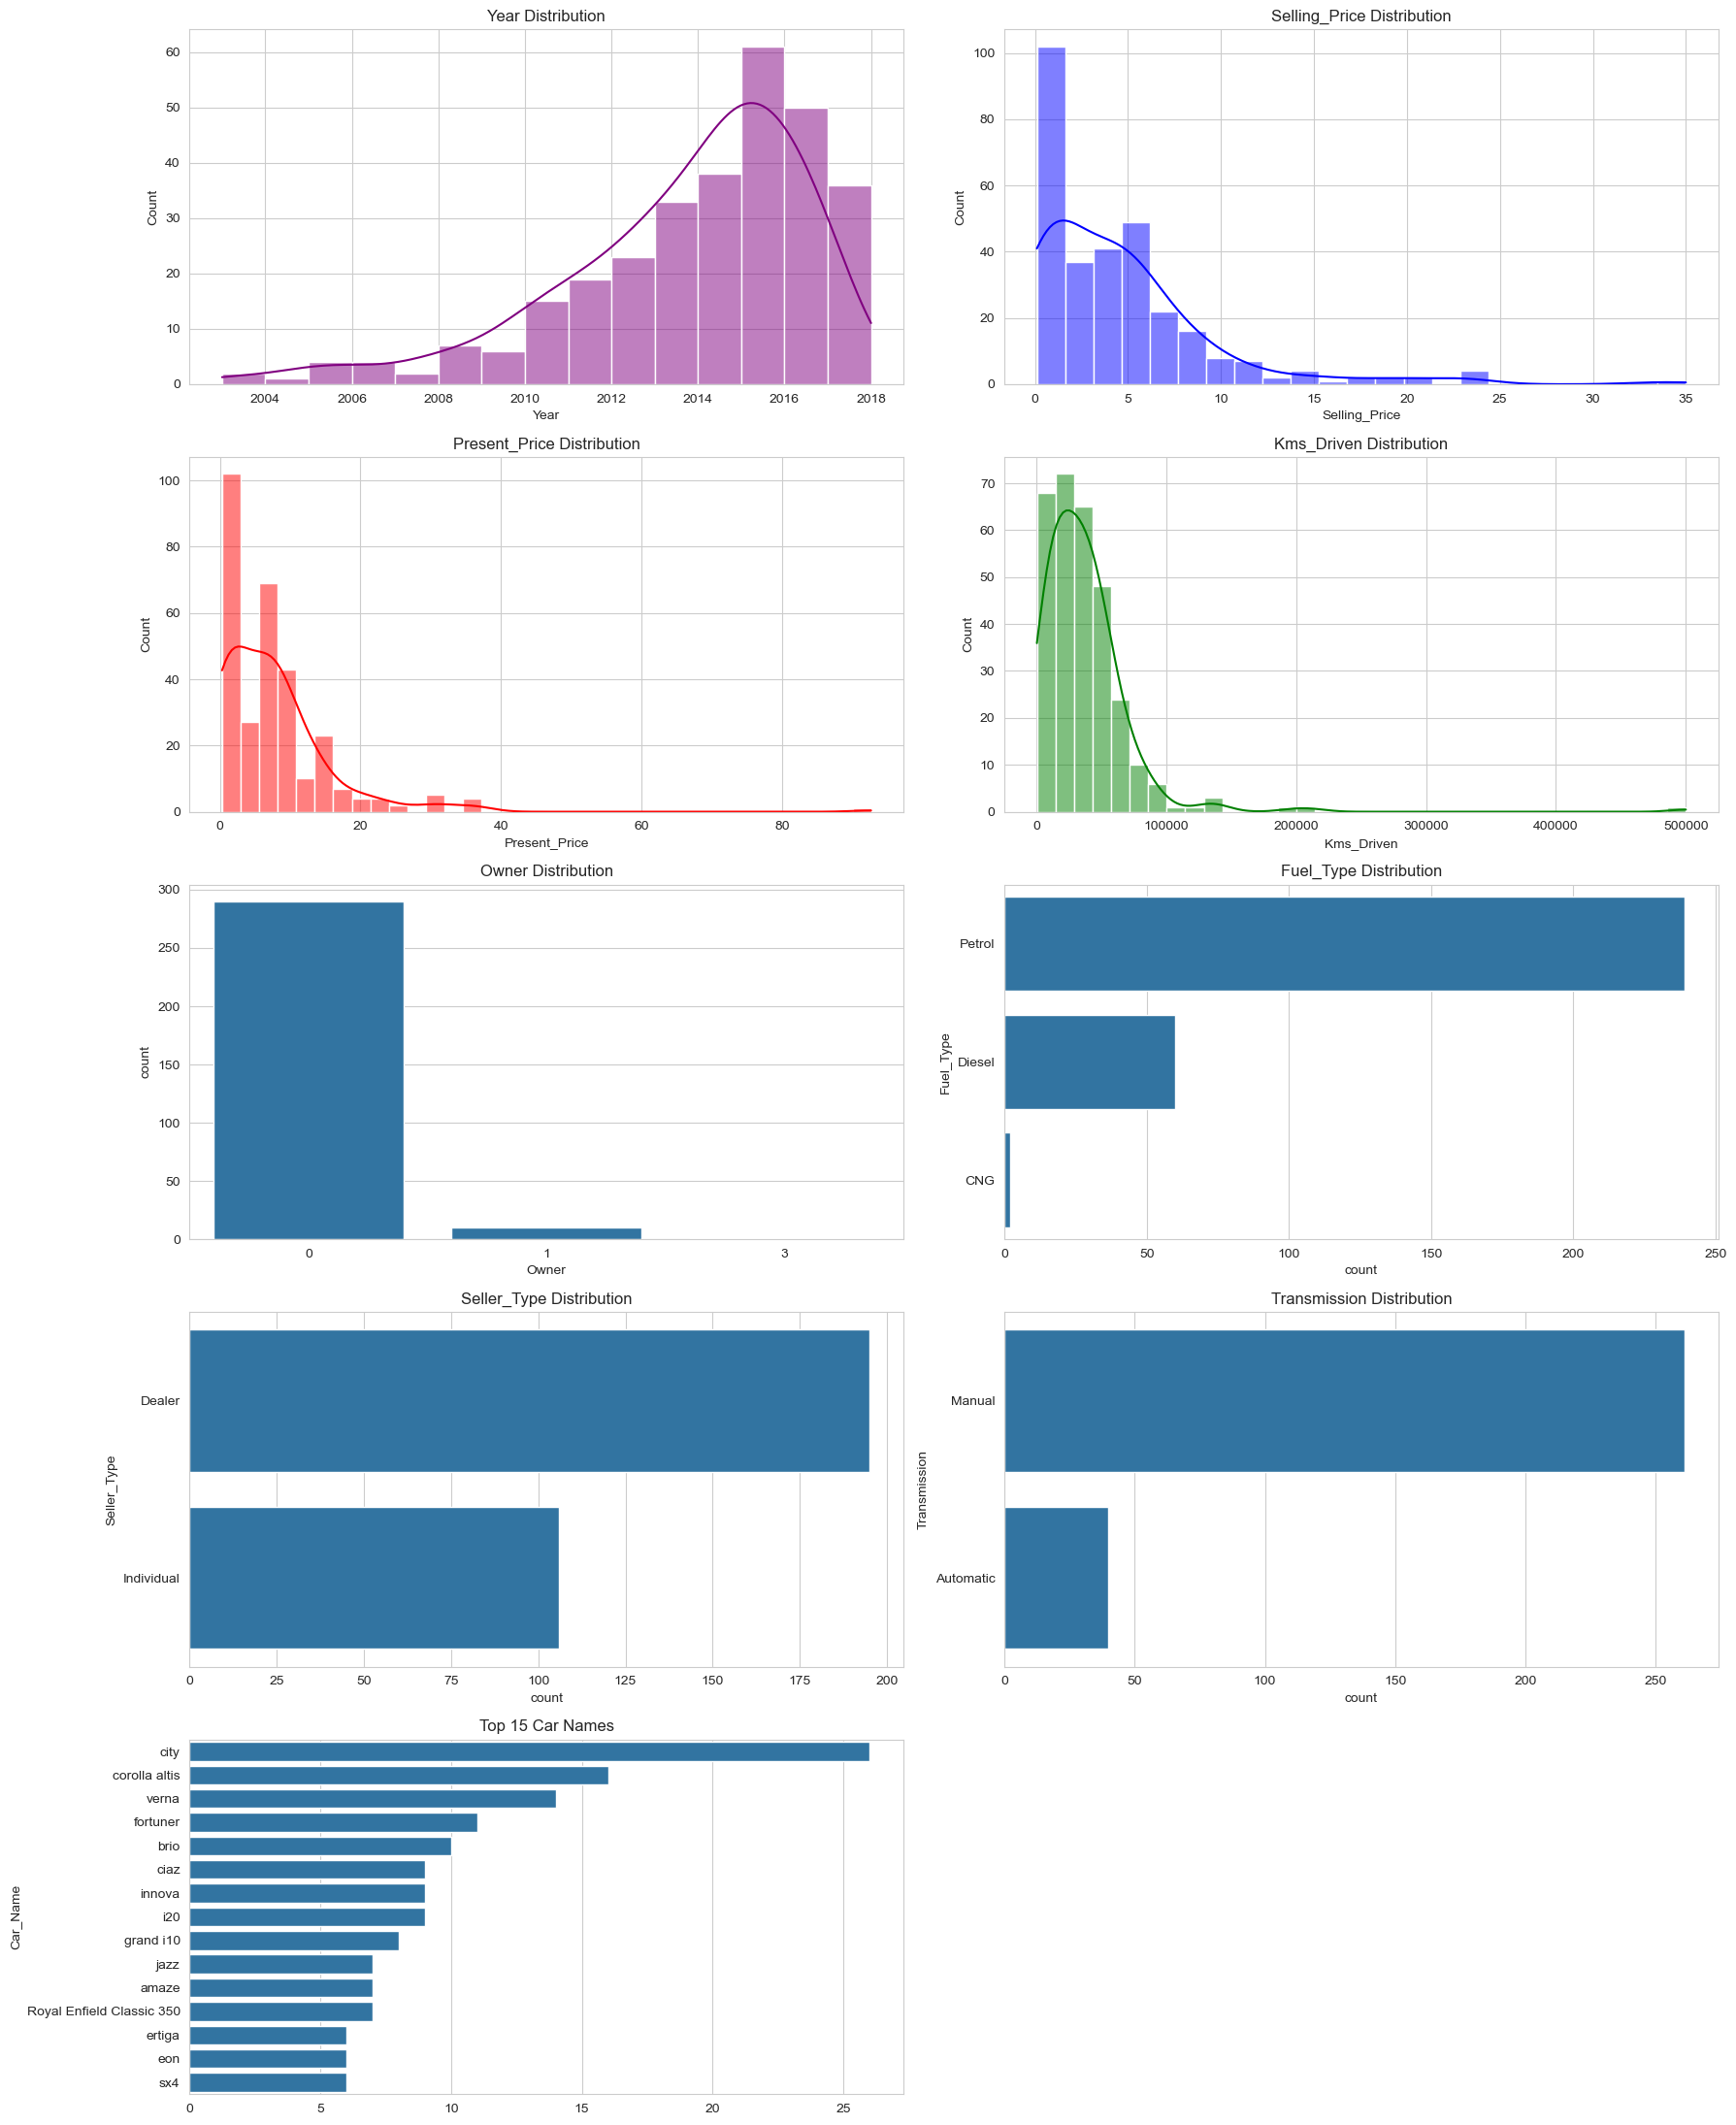

In [8]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(5, 2, figsize=(18, 22))


sns.histplot(df['Year'], bins=15, kde=True, ax=axes[0, 0], color='purple')
axes[0, 0].set_title('Year Distribution')

sns.histplot(df['Selling_Price'], kde=True, ax=axes[0, 1], color='blue')
axes[0, 1].set_title('Selling_Price Distribution')

sns.histplot(df['Present_Price'], kde=True, ax=axes[1, 0], color='red')
axes[1, 0].set_title('Present_Price Distribution')

sns.histplot(df['Kms_Driven'], kde=True, ax=axes[1, 1], color='green')
axes[1, 1].set_title('Kms_Driven Distribution')

sns.countplot(x='Owner', data=df, ax=axes[2, 0])
axes[2, 0].set_title('Owner Distribution')


sns.countplot(y='Fuel_Type', data=df, ax=axes[2, 1])
axes[2, 1].set_title('Fuel_Type Distribution')

sns.countplot(y='Seller_Type', data=df, ax=axes[3, 0])
axes[3, 0].set_title('Seller_Type Distribution')

sns.countplot(y='Transmission', data=df, ax=axes[3, 1])
axes[3, 1].set_title('Transmission Distribution')


top_cars = df['Car_Name'].value_counts().head(15)

sns.barplot(
    x=top_cars.values,
    y=top_cars.index,
    ax=axes[4, 0]
)
axes[4, 0].set_title('Top 15 Car Names')

fig.delaxes(axes[4, 1])

plt.tight_layout()
plt.show()

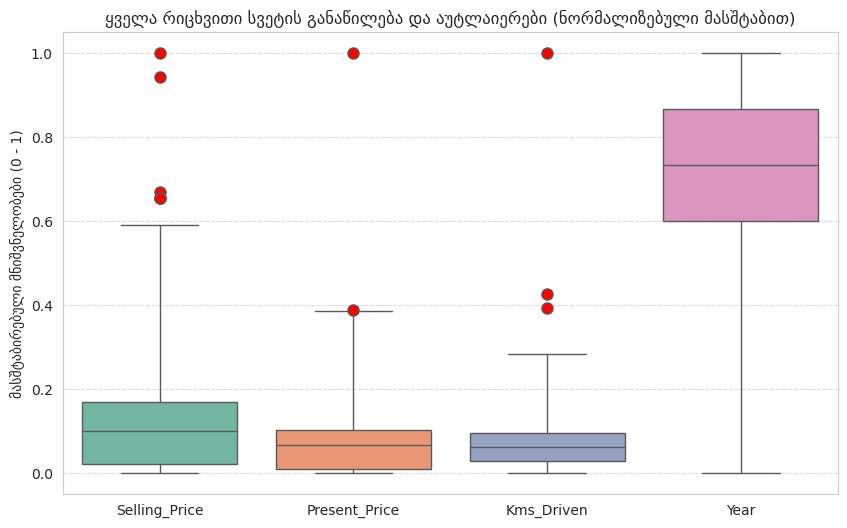

In [61]:
outlier_style = {"markerfacecolor": "red", "marker": "o", "markersize": 8}

numerical_cols = ["Selling_Price", "Present_Price", "Kms_Driven", "Year"]

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[numerical_cols]), columns=numerical_cols)
plt.rcParams['font.family'] = 'DejaVu Sans'

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_scaled, 
    palette="Set2", 
    flierprops=outlier_style,
    whis=3
)

plt.title("ყველა რიცხვითი სვეტის განაწილება და აუტლაიერები (ნორმალიზებული მასშტაბით)")
plt.ylabel("მასშტაბირებული მნიშვნელობები (0 - 1)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [62]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR

    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

  
    if len(col_outliers) > 0:
        print(f" სვეტი '{col}' - გრაფაზე სულ არის {len(col_outliers)} წერტილი:")
        print(
            col_outliers[
                ["Car_Name", "Year", "Selling_Price", "Present_Price", "Kms_Driven"]
            ]
        )
        print("-" * 60)

 სვეტი 'Selling_Price' - გრაფაზე სულ არის 6 წერტილი:
        Car_Name  Year  Selling_Price  Present_Price  Kms_Driven
51      fortuner  2015           23.0          30.61       40000
63      fortuner  2015           23.5          35.96       47000
64      fortuner  2017           33.0          36.23        6000
82        innova  2017           23.0          25.39       15000
86  land cruiser  2010           35.0          92.60       78000
93      fortuner  2015           23.0          30.61       40000
------------------------------------------------------------
 სვეტი 'Present_Price' - გრაფაზე სულ არის 2 წერტილი:
        Car_Name  Year  Selling_Price  Present_Price  Kms_Driven
64      fortuner  2017           33.0          36.23        6000
86  land cruiser  2010           35.0          92.60       78000
------------------------------------------------------------
 სვეტი 'Kms_Driven' - გრაფაზე სულ არის 3 წერტილი:
          Car_Name  Year  Selling_Price  Present_Price  Kms_Driven
84   

მონაცემების არასწორი შეყვანა:
Activa 3g (2008 წელი) — გარბენი 500,000 კმ
Activa  არის პატარა ქალაქის სკუტერი.ფიზიკურად შეუძლებელია სკუტერმა ნახევარი მილიონი კილომეტრი გაიაროს, მისი ძრავი ამდენს ვერ გაუძლებს.

Honda Karizma (2010 წელი) — გარბენი 213,000 კმ
მოტოციკლისთვის 213 ათასი კმ ძალზედ ბევრია.

სრულიად ბუნებრივი, რეალური ანომალიები:
Land Cruiser — საწყისი ფასი 92.60, გასაყიდი 35.0
ტოიოტა ლენდ კრუიზერი არის პრემიუმ კლასის. ის სალონშიც ძვირი ღირს და მეორად ბაზარზეც ძალიან ნელა კარგავს ფასს. ეს შეცდომა არ არის, უბრალოდ მდიდრული მანქანაა დატასეტში.

Fortuner და Innova (გასაყიდი ფასები 23.0 – 33.0)
Fortuner და Innova არის დიდი მინივენი, რომლებიც ინდოეთის ბაზარზე (საიდანაც ეს დატასეტია) უზომოდ პოპულარული და ძვირადღირებულია. 2015-2017 წლის მოდელები რომ ძვირად იყიდება,სრულიად ლოგიკურია.

Innova (2005 წელი) — გარბენი 197,176 კმ
2005 წლის ძველი მანქანისთვის ეს აბსოლუტურად რეალური და ბუნებრივი გარბენია.


In [63]:
bad_rows = df[
    ((df["Car_Name"] == "Activa 3g") & (df["Kms_Driven"] > 150000)) |
    ((df["Car_Name"] == "Honda Karizma") & (df["Kms_Driven"] > 150000))
].index

df.drop(index=bad_rows, inplace=True)

In [64]:

df["Car_Age"] = 2026 - df["Year"]

num_features = ["Present_Price", "Kms_Driven", "Owner", "Car_Age"]
cat_features = ["Fuel_Type", "Seller_Type", "Transmission"]
target = "Selling_Price"  

# ციფრული მონაცემების Pipeline (მხოლოდ მასშტაბირება)
num_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

#კატეგორიული მონაცემების Pipeline ( One-Hot Encoding)
cat_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(drop="first", sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features),
    ]
)

X_transformed = preprocessor.fit_transform(df[num_features + cat_features])

encoded_cat_names = preprocessor.named_transformers_["cat"]["encoder"].get_feature_names_out(cat_features)
all_feature_names = num_features + list(encoded_cat_names)

df_processed = pd.DataFrame(X_transformed, columns=all_feature_names)
df_processed["Selling_Price"] = df[target].values

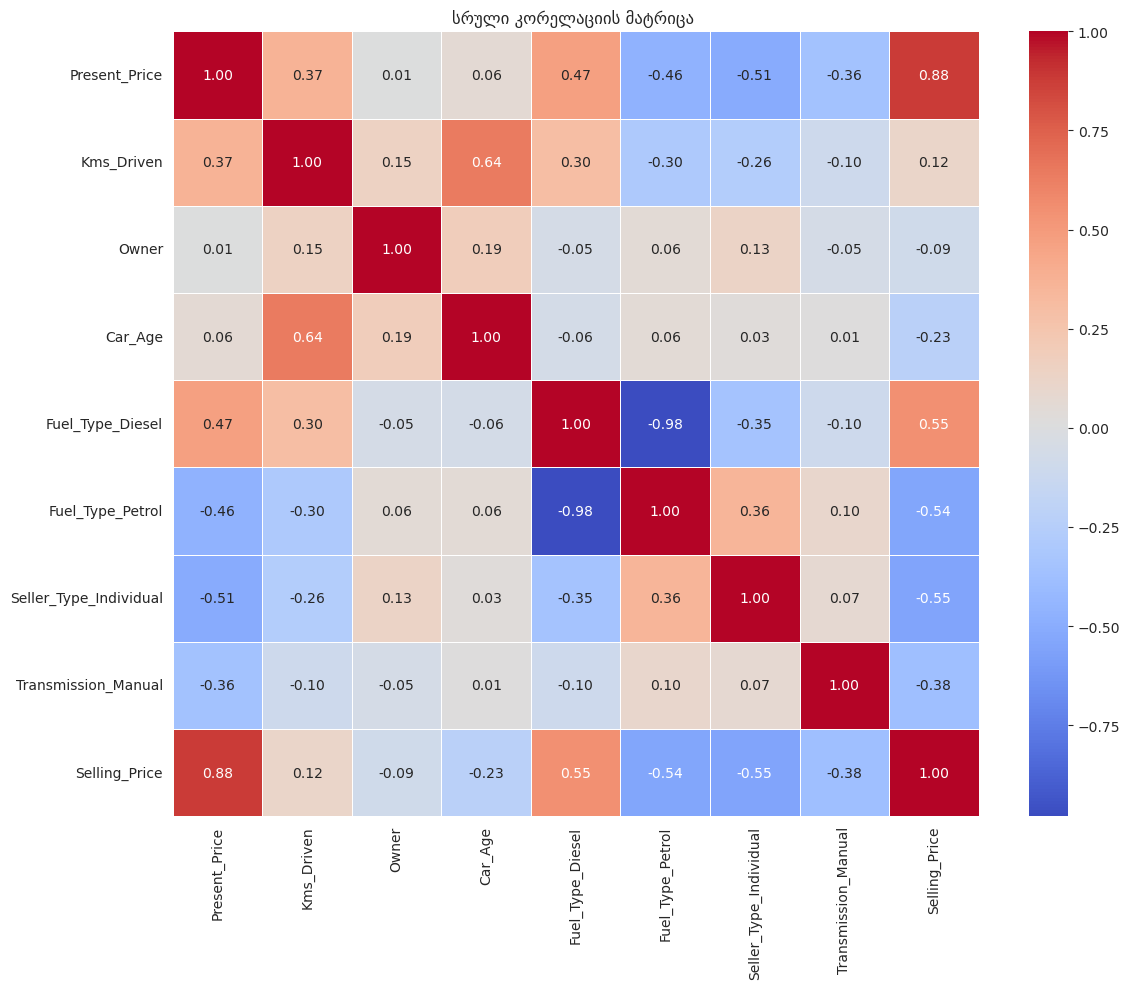

In [65]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df_processed.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
)

plt.title("სრული კორელაციის მატრიცა ")
plt.tight_layout()
plt.show()

ყველაზე ძლიერი კავშირი: Selling_Price და Present_Price (0.88)
რაც უფრო ძვირი ღირდა მანქანა თავიდან სალონში (Present_Price), მით უფრო ძვირად იყიდება ის მეორად ბაზარზეც (Selling_Price)

დროისა და გარბენის ლოგიკა (Age და Kms_Driven = 0.64)
ძველ მანქანებს გზაზე მეტი დრო აქვთ გატარებული და შესაბამისად, გარბენიც მეტი დაუგროვდათ

გარბენის გავლენა: Selling_Price და Kms_Driven (0.12)
წესით, დიდ გარბენიანი მანქანა იაფი უნდა იყოს (უარყოფითი კორელაცია), მაგრამ აქ კავშირი თითქმის არ ჩანს, რადგან ბაზაში გვყავს დიდი ჯიპები (Innova, Fortuner), რომლებსაც ბუნებრივადაც დიდი გარბენი აქვთ (100k+ კმ), მაგრამ მაინც ძვირად ფასობენ, რადგან გამძლე და პრემიუმ მანქანებია

ასაკის გავლენა ფასზე (Selling_Price და Age = -0.23)
რაც უფრო იზრდება მანქანის ასაკი (Age), მით უფრო მცირდება მისი გასაყიდი ფასი . კავშირი ზომიერია, რადგან დატასეტში გვყავს პრემიუმ ჯიპები (მაგ. Land Cruiser), რომლებიც დიდი ასაკის მიუხედავად, მაინც ძვირად ფასობენ.

Fuel_Type_Diesel (0.55): ძლიერი დადებითი კავშირია.დიზელის ძრავიანი მანქანები გაცილებით ძვირად იყიდება.
Fuel_Type_Petrol (-0.54): ძლიერი უარყოფითი კავშირია. ბენზინის მანქანებზე ფასი საგრძნობლად კლებულობს.

Seller_Type_Individual (-0.55)გამყიდველი არის ფიზიკური პირი, მანქანის ფასი მკვეთრად დაბალია. შესაბამისად, დილერები  მანქანებს ბევრად უფრო ძვირად ყიდიან.

გადაცემათა კოლოფი: Transmission_Manual (-0.38)თუ მანქანა არის მექანიკა, მისი ფასი უფრო დაბალია. ავტომატური გადაცემათა კოლოფის მქონე ავტომობილები მეორად ბაზარზე მეტად ფასობს.

In [66]:
if "Fuel_Type_Petrol" in df_processed.columns:
    df_processed = df_processed.drop(columns=["Fuel_Type_Petrol"])

Fuel_Type_Petrol' წინასწარ ჩამოშორდა VIF-ის გაჯანსაღებისთვის, რადგან Fuel_Type_Petrol და Fuel_Type_Diesel სრულყოფილად (თითქმის 100%-ით) განსაზღვრავდნენ ერთმანეთს, რაც მათემატიკურად იწვევდა გიჟურ მულტიკოლინეარობას და ზრდიდა მოდელის კოეფიციენტების ცდომილებას.

In [67]:
print("--- მულტიკოლინეარობის (VIF) ანალიზი ---")

X_vif_features = df_processed.drop(columns=["Selling_Price"], errors="ignore")

X_vif_features = add_constant(X_vif_features)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_features.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif_features.values, i)
    for i in range(X_vif_features.shape[1])
]
vif_data = vif_data[vif_data["Feature"] != "const"].reset_index(drop=True)
print(vif_data)

if "Selling_Price" not in df_processed.columns:
    df_processed["Selling_Price"] = df[target].values

--- მულტიკოლინეარობის (VIF) ანალიზი ---
                  Feature       VIF
0           Present_Price  1.896830
1              Kms_Driven  2.337401
2                   Owner  1.066625
3                 Car_Age  1.998064
4        Fuel_Type_Diesel  1.440212
5  Seller_Type_Individual  1.467628
6     Transmission_Manual  1.180457


დამოუკიდებელ მახასიათებლებს შორის წრფივი დამოკიდებულება სრულად მართვადია. ვინაიდან არცერთი ცვლადის VIF არ აჭარბებს კრიტიკულ 5-იან ზღვარს.

In [68]:
X = df.drop(columns=["Selling_Price"])
y = df["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [69]:
base_models = {
    "Linear Regression": Pipeline([
        ("preprocessing", preprocessor),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("preprocessing", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessing", preprocessor),
        ("model", DecisionTreeRegressor(max_depth=5, random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("preprocessing", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=5,
            random_state=42
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("preprocessing", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ))
    ])
}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring_methods = {
    "R²": "r2",
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error"
}

print("მოდელების დეტალური კროს-ვალიდაცია (სტაბილურობის შემოწმება):")

for name, pipeline in base_models.items():

    print(f"\nმოდელი: {name}")

    for metric_name, scoring in scoring_methods.items():

        scores = cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv=kf,
            scoring=scoring
        )

        mean_score = -scores.mean() if scoring.startswith("neg") else scores.mean()
        std_score = scores.std()

        print(
            f"   {metric_name}: {mean_score:.4f}"
        )

მოდელების დეტალური კროს-ვალიდაცია (სტაბილურობის შემოწმება):

მოდელი: Linear Regression
   R²: 0.8011
   MAE: 1.2385
   RMSE: 2.0798

მოდელი: Ridge Regression
   R²: 0.8036
   MAE: 1.2380
   RMSE: 2.0699

მოდელი: Decision Tree
   R²: 0.5751
   MAE: 1.3125
   RMSE: 2.9692

მოდელი: Random Forest
   R²: 0.8461
   MAE: 0.8834
   RMSE: 1.8276

მოდელი: Gradient Boosting
   R²: 0.8027
   MAE: 0.8464
   RMSE: 1.9771


მოდელის სტაბილურობის შემოწმება (CV): კროს-ვალიდაციით დავამტკიცე, რომ არჩეული ალგორითმები არ არიან მგრძნობიარენი მონაცემების შემთხვევითი გაყოფის მიმართ.შედეგები მაღალი და სტაბილურია. ანსამბლური მეთოდების უპირატესობა ხაზოვან მოდელებთან შედარებით კი აჩვენებს, რომ მათ წარმატებით აითვისეს მონაცემებში არსებული რთული კავშირები.ყველაზე კარგ შედეგს Random Forest აჩვენებს.მას აქვს ყველაზე მაღალი R^2(0.85) და  დაბალი ცდომილება (MAE: 0.88, RMSE: 1.8), რაც მიუთითებს იმაზე, რომ ის ყველაზე ზუსტად და სტაბილურად აკეთებს პროგნოზებს.მას შემდეგ მოჰყვება Gradient Boosting შედეგებით.

In [70]:
estimators = [
    ("lr", Pipeline([
        ("preprocessing", preprocessor),
        ("model", LinearRegression())
    ])),
    ("dt", Pipeline([
        ("preprocessing", preprocessor),
        ("model", DecisionTreeRegressor(max_depth=5, random_state=42))
    ])),
    ("rf", Pipeline([
        ("preprocessing", preprocessor),
        ("model", RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42))
    ])),
    ("gb", Pipeline([
        ("preprocessing", preprocessor),
        ("model", GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
    ]))
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5
)

all_models = base_models.copy()
all_models["Stacking Ensemble"] = stacking_model

In [71]:
results_list = []

for name, model in all_models.items():
    model.fit(X_train, y_train)
    
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    

    results_list.append({"Model": name, "Dataset": "Train", 
                         "MAE": metrics.mean_absolute_error(y_train, train_preds),
                         "RMSE": np.sqrt(metrics.mean_squared_error(y_train, train_preds)),
                         "R²": metrics.r2_score(y_train, train_preds)})
    
    results_list.append({"Model": name, "Dataset": "Test", 
                         "MAE": metrics.mean_absolute_error(y_test, test_preds),
                         "RMSE": np.sqrt(metrics.mean_squared_error(y_test, test_preds)),
                         "R²": metrics.r2_score(y_test, test_preds)})

df = pd.DataFrame(results_list)
final_table = df.set_index(['Model', 'Dataset'])

print(final_table.round(4))

                              MAE    RMSE      R²
Model             Dataset                        
Linear Regression Train    1.0973  1.6539  0.8838
                  Test     1.1955  1.7976  0.9055
Ridge Regression  Train    1.1005  1.6555  0.8835
                  Test     1.1896  1.8053  0.9047
Decision Tree     Train    0.5150  0.8117  0.9720
                  Test     0.7066  1.1174  0.9635
Random Forest     Train    0.4806  0.8731  0.9676
                  Test     0.5950  1.0173  0.9697
Gradient Boosting Train    0.2291  0.3093  0.9959
                  Test     0.4932  0.8384  0.9794
Stacking Ensemble Train    0.5890  0.8398  0.9700
                  Test     0.7103  1.0373  0.9685


საუკეთესო შემსრულებელი Gradient Boosting. მას აქვს ყველაზე მაღალი R^2 (0.9794) და ყველაზე დაბალი RMSE (0.8384) Test მონაცემებზე. მიუხედავად იმისა, რომ Train R² არის 0.9959 (ძალიან მაღალი), Test R² არის 0.9794. სხვაობა ძალიან მცირეა, რაც მიუთითებს იმაზე,რომ მოდელმა შეძლო მონაცემებში არსებული რთული კანონზომიერებების სწორად ათვისება და არა უბრალოდ "დაზეპირება". ეს მოდელი აშკარად ლიდერობს სიზუსტეში.ძალიან ძლიერი ალტერნატივაა Random Forest.ის გამოირჩევა ძალიან კარგი ბალანსით Train და Test შედეგებს შორის.მას მოსდევს Stacking Ensemble.
საშუალო შედეგი აჩვენა  Linear და Ridge Regression.ისინი არ არიან ისეთი ზუსტი, როგორც ანსამბლური მეთოდები, მაგრამ მათი შედეგები საკმაოდ სტაბილურია.
ყველა მოდელის შემთხვევაში Test შედეგები თითქმის ისეთივე კარგია, როგორც Train, ეს ნიშნავს, რომ მონაცემები ძალიან მაღალი ხარისხისაა.

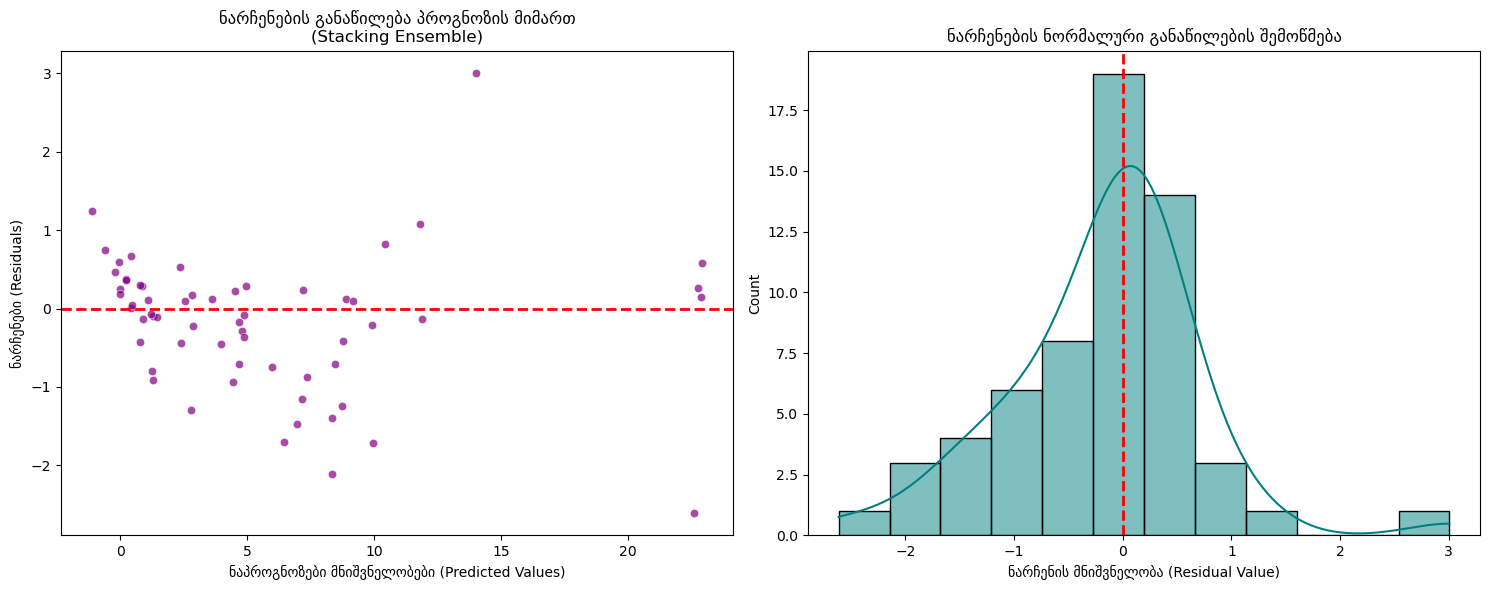

In [89]:
# ნარჩენების გამოთვლა (Residuals = Actual - Predicted)
residuals = y_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(x=best_preds, y=residuals, ax=axes[0], color="purple", alpha=0.7)
axes[0].axhline(y=0, color="red", linestyle="--", linewidth=2)
axes[0].set_xlabel("ნაპროგნოზები მნიშვნელობები (Predicted Values)")
axes[0].set_ylabel("ნარჩენები (Residuals)")
axes[0].set_title(f"ნარჩენების განაწილება პროგნოზის მიმართ\n({best_model_name})")

sns.histplot(residuals, kde=True, ax=axes[1], color="teal")
axes[1].axvline(x=0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("ნარჩენის მნიშვნელობა (Residual Value)")
axes[1].set_title("ნარჩენების ნორმალური განაწილების შემოწმება")

plt.tight_layout()
plt.show()

წერტილები მჭიდროდ არის შემოკრებილი წითელი ხაზის (0-ის) გარშემო. წერტილები მეტ-ნაკლებად თანაბრადაა გაბნეული, თუმცა მარჯვენა მხარეს  სადაც პროგნოზი იზრდება  წერტილები უფრო მეტად იფანტება. ეს ნიშნავს, რომ მოდელი უფრო ზუსტია დაბალ ფასებზე, ხოლო მაღალ ფასებზე ცდომილება იზრდება.
არის ორი წერტილი: ერთი ზემოთ (+3-თან) და ერთი ქვემოთ (-2.5-თან). ესენი არის მანქანები, რომელთა რეალური ფასი მოდელის მიერ ნაჩვენები ფასისგან მკვეთრად განსხვავდება. ეს ნიშნავს,რომ მონაცემებში არის უნიკალური შემთხვევები, რომლებსაც მოდელი ვერ აზუსტებს.

ნარჩენების განაწილება (ნორმალურობის შემოწმება):
ნარჩენების ჰისტოგრამა მკაფიოდ გამოხატავს ნორმალური განაწილების („ზარისებურ“) ფორმას, რომელიც იდეალურად ცენტრდება ნულზე,რაც ნიშნავს, რომ მოდელის შეცდომების საშუალო ნულია. მოდელის შეცდომები არის შემთხვევითი ხასიათის და არა სისტემური. ეს არის იდეალური მდგომარეობა,რადგან  რომ მოდელი არ არის მიკერძოებული (Unbiased).ის არ სჭარბებს ან აკლებს ფასს მუდმივად ერთი მიმართულებით.
მაგრამ გრაფიკი ოდნავ მარჯვნივ არის წამოსული (მცირე დადებითი ასიმეტრია). მონაცემებში არის რამდენიმე შემთხვევა, სადაც მოდელმა ფასი იმაზე მეტად დააკლო, ვიდრე რეალური იყო (მოდელი ცდება მაღალი ფასისკენ).

In [73]:
new_car = pd.DataFrame({
    "Present_Price": [8.5],
    "Kms_Driven": [45000],
    "Owner": [0],
    "Car_Age": [5],
    "Fuel_Type": ["Petrol"],
    "Seller_Type": ["Dealer"],
    "Transmission": ["Manual"]
})

best_model = all_models["Gradient Boosting"]

prediction = best_model.predict(new_car)

print(f"სავარაუდო ფასი: {prediction[0]:.2f}")

სავარაუდო ფასი: 6.76
